## 0. 프로젝트 목표와 이번 분석의 위치

본 프로젝트의 주제는 **Steam 인디게임 반응 분석을 통한 개발 의사결정 지원**이다.

프로젝트는 크게 두 관점으로 나뉜다.

| 관점 | 목적 |
| --- | --- |
| 출시 전 관점 | 장르, 태그, 플레이 방식, 가격대 등 게임 속성과 초기 반응 지표를 비교해 출시 전략에 참고할 수 있는 근거를 만든다. |
| 출시 후 관점 | 특정 게임의 리뷰 수, 긍정률, 리뷰 본문을 바탕으로 유저 반응의 원인을 해석하고, 부정 리뷰의 반복 이슈를 유형화해 패치 및 운영 우선순위를 제안한다. |

이번 LLM 리뷰 감성분석은 **출시 전 관점**에 해당한다.

즉, 특정 게임 1개의 패치 우선순위를 정하는 분석이 아닌  
**Action 장르 인디게임의 출시 초기 리뷰를 LLM으로 분석해 해당 장르 유저들이 긍정적으로 평가한 요소와 불편하게 느낀 요소를 도출**하는 분석이다.

따라서 본 분석 결과는 Action 장르 게임을 개발하거나 출시 준비 중인 인디 개발자가 출시 전 단계에서 어떤 요소를 우선 점검해야 하는지 판단하는 참고 근거로 활용한다.

> 추후엔 Action 외의 다양한 장르를 시도할 예정

In [2]:
# ============================================================
# 0. 라이브러리 불러오기
# ============================================================

import platform
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display, Markdown

if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":  # macOS
    plt.rcParams["font.family"] = "AppleGothic"
else:  # Linux
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (12, 6)

# pandas 출력 옵션
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

# ============================================================
# 1. 파일 경로 설정
# ============================================================
ROOT = Path(r"C:\Users\joon5\Documents\github\steam-indie-game-analysis")
RUN_NAME = "main_action_d0_d30"

OUTPUT_DIR = ROOT / "data" / "outputs" / RUN_NAME

RESULT_PATH = OUTPUT_DIR / "llm_review_analysis_result.csv"
TAG_PATH = OUTPUT_DIR / "llm_issue_tags_flat.csv"
ISSUE_PRIORITY_PATH = OUTPUT_DIR / "llm_issue_priority_summary.csv"

# ============================================================
# 2. 데이터 불러오기
# ============================================================
df_result = pd.read_csv(RESULT_PATH)
df_tags = pd.read_csv(TAG_PATH)
df_issue = pd.read_csv(ISSUE_PRIORITY_PATH)

# 보고서에서는 LLM 분석에 성공한 리뷰만 사용한다.
if "analysis_status" in df_result.columns:
    df_result = df_result[df_result["analysis_status"] == "success"].copy()

# 날짜 컬럼 정리
for col in ["review_datetime", "release_date"]:
    if col in df_result.columns:
        df_result[col] = pd.to_datetime(df_result[col], errors="coerce")

# ============================================================
# 3. 기본 표시 설정
# ============================================================
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

# ============================================================
# 4. 이슈명 한글 정리
# ============================================================
ISSUE_KR_MAP = {
    "positive_praise": "긍정 칭찬",
    "gameplay_loop": "게임플레이 루프",
    "content_volume": "콘텐츠 분량",
    "control": "조작감",
    "difficulty": "난이도",
    "multiplayer_network": "멀티/네트워크",
    "ui_ux": "UI/UX",
    "bug": "버그",
    "balance": "밸런스",
    "price_value": "가격/가치",
    "crash": "크래시",
    "performance": "성능",
    "other": "기타",
    "graphics_audio": "그래픽/사운드",
    "translation_localization": "번역/현지화",
    "developer_communication": "개발사 소통",
    "progression_grind": "성장/반복 노가다",
    "story": "스토리",
    "optimization": "최적화",
    "monetization": "과금/수익화",
    "save_progression": "저장/진행",
    "technical_stability": "기술 안정성",
}

print("결과 파일:", RESULT_PATH)
print("이슈 태그 파일:", TAG_PATH)
print("분석 리뷰 수:", len(df_result))
print("분석 게임 수:", df_result["appid"].nunique())
print("이슈 태그 수:", len(df_tags))

결과 파일: C:\Users\joon5\Documents\github\steam-indie-game-analysis\data\outputs\main_action_d0_d30\llm_review_analysis_result.csv
이슈 태그 파일: C:\Users\joon5\Documents\github\steam-indie-game-analysis\data\outputs\main_action_d0_d30\llm_issue_tags_flat.csv
분석 리뷰 수: 206
분석 게임 수: 28
이슈 태그 수: 676


## 1. 분석 목적

이번 분석의 목적은 다음과 같다.

1. Action 장르 인디게임의 출시 초기 리뷰를 LLM으로 분석한다.
2. 해당 장르 유저들이 긍정적으로 평가한 요소와 불편하게 느낀 요소를 분리한다.
3. 긍정 리뷰 안에 포함된 개선 요구와 부정 리뷰 안에 포함된 장르 기대치를 함께 확인한다.
4. 반복적으로 등장하는 불편 요소를 유형화하여 출시 전 점검 항목으로 연결한다.
5. 최종적으로 Action 장르 인디게임 개발자에게 **출시 전 기획·개발 단계에서 무엇을 점검해야 하는지** 제안한다.

## 2. 분석 대상 및 기준

이번 분석은 Action 계열 인디게임 표본의 출시 초기 리뷰를 대상으로 한다.  
리뷰는 출시 후 초기 구간인 `D0-D7`, `D8-D30`에 작성된 리뷰를 중심으로 분석하였다.

아래 표는 이번 LLM 분석의 기본 범위와 조건이다.

| 항목 | 내용 |
| --- | --- |
| 분석 대상 장르 | Action 계열 stratum |
| 출시일 기준 | 2024-01-01 이후 |
| 리뷰 언어 | English |
| 리뷰 구간 | D0-D7, D8-D30 |
| 리뷰 조건 | Steam 구매 리뷰, 무료 수령 리뷰 제외, 얼리액세스 리뷰 제외 |
| 게임당 샘플 수 | 최대 12개 |
| 샘플링 방식 | Steam 긍정/부정 라벨 균형 샘플링 |
| 최종 분석 리뷰 수 | 206개 |
| 최종 분석 게임 수 | 28개 |

## 3. 전체 LLM 분석 결과 요약

Steam의 추천/비추천 라벨은 유저가 최종적으로 게임을 추천했는지를 보여준다.  
반면 LLM 감성분석은 리뷰 본문을 읽고 긍정, 부정, 혼합, 중립을 더 세부적으로 구분한다.

따라서 두 지표의 차이를 보면, Action 장르 유저가 게임을 추천하면서도 어떤 불편을 함께 남기는지 확인할 수 있다.

,항목,값
0,분석 리뷰 수,206
1,분석 게임 수,28
2,Steam 긍정 리뷰 비율,72.3%
3,LLM 긍정 리뷰 비율,60.2%
4,LLM 부정+혼합 리뷰 비율,38.8%
5,High 긴급도 리뷰 비율,28.2%
6,Steam 라벨-LLM 감정 완전 일치 비율,85.4%
7,Steam 라벨-LLM 감정 부분 일치 비율,13.6%


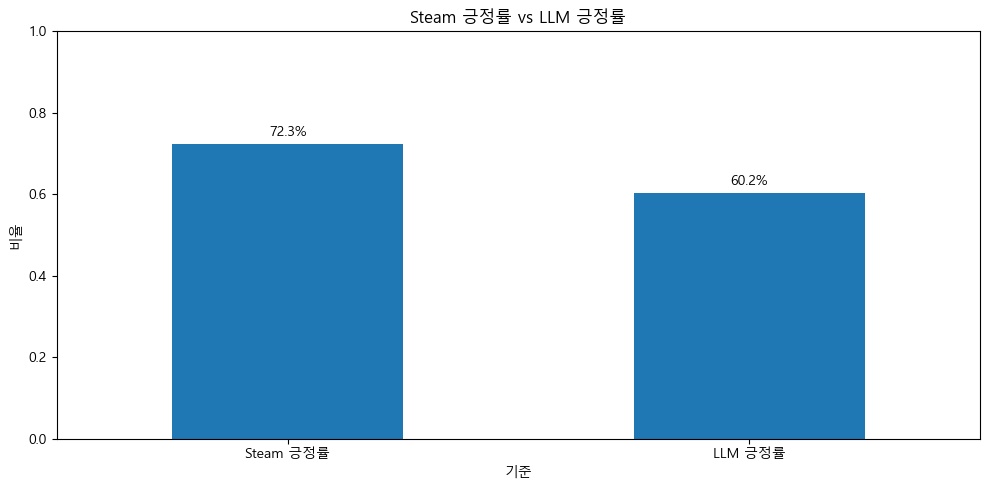

,LLM 감정,리뷰 수,비율
0,positive,124,60.2
1,mixed,28,13.6
2,negative,52,25.2
3,neutral,2,1.0


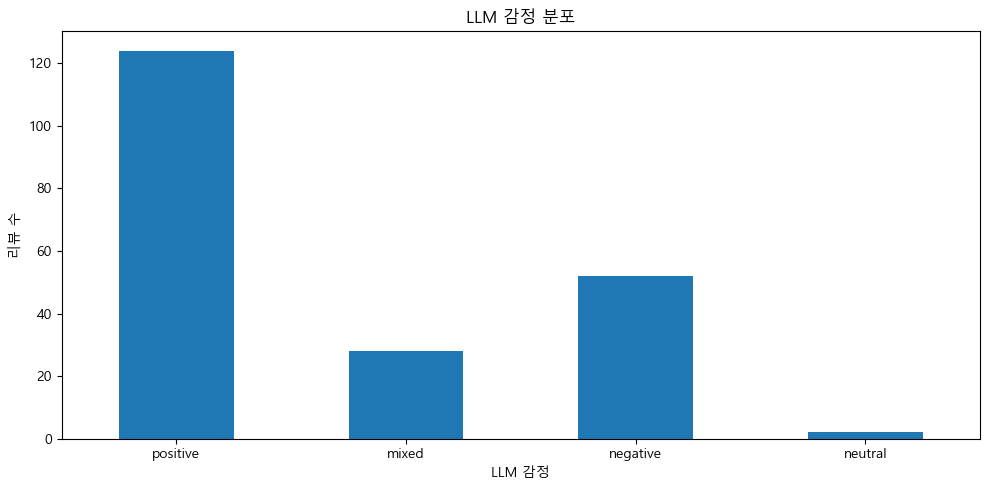

In [3]:
# ============================================================
# 전체 LLM 분석 결과 요약표
# ============================================================
overall_summary = pd.DataFrame({
    "항목": [
        "분석 리뷰 수",
        "분석 게임 수",
        "Steam 긍정 리뷰 비율",
        "LLM 긍정 리뷰 비율",
        "LLM 부정+혼합 리뷰 비율",
        "High 긴급도 리뷰 비율",
        "Steam 라벨-LLM 감정 완전 일치 비율",
        "Steam 라벨-LLM 감정 부분 일치 비율",
    ],
    "값": [
        f"{len(df_result):,}",
        f"{df_result['appid'].nunique():,}",
        f"{df_result['steam_label_text'].eq('positive').mean() * 100:.1f}%",
        f"{df_result['llm_sentiment'].eq('positive').mean() * 100:.1f}%",
        f"{df_result['llm_sentiment'].isin(['negative', 'mixed']).mean() * 100:.1f}%",
        f"{df_result['urgency'].eq('high').mean() * 100:.1f}%",
        f"{df_result['sentiment_relation'].eq('exact_match').mean() * 100:.1f}%",
        f"{df_result['sentiment_relation'].eq('partial_match').mean() * 100:.1f}%",
    ]
})

display(overall_summary)

# ============================================================
# 그래프 1. Steam 긍정률과 LLM 긍정률 비교
# ============================================================
sentiment_compare = pd.DataFrame({
    "기준": ["Steam 긍정률", "LLM 긍정률"],
    "비율": [
        df_result["steam_label_text"].eq("positive").mean(),
        df_result["llm_sentiment"].eq("positive").mean(),
    ]
})

ax = sentiment_compare.plot(kind="bar", x="기준", y="비율", legend=False, rot=0)
ax.set_title("Steam 긍정률 vs LLM 긍정률")
ax.set_ylabel("비율")
ax.set_ylim(0, 1)
for i, value in enumerate(sentiment_compare["비율"]):
    ax.text(i, value + 0.02, f"{value * 100:.1f}%", ha="center")
plt.tight_layout()
plt.show()

# ============================================================
# 그래프 2. LLM 감정 분포
# ============================================================
llm_order = ["positive", "mixed", "negative", "neutral"]

llm_dist = (
    df_result["llm_sentiment"]
    .value_counts()
    .reindex(llm_order)
    .dropna()
    .reset_index()
)

llm_dist.columns = ["LLM 감정", "리뷰 수"]

# 비율 계산
llm_dist["비율"] = (llm_dist["리뷰 수"] / llm_dist["리뷰 수"].sum() * 100).round(1)

display(llm_dist)

ax = llm_dist.plot(kind="bar", x="LLM 감정", y="리뷰 수", legend=False, rot=0)
ax.set_title("LLM 감정 분포")
ax.set_ylabel("리뷰 수")
plt.tight_layout()
plt.show()

### 결과 해석

Steam 라벨 기준 긍정 리뷰 비율은 **72.3%**였지만, LLM이 리뷰 본문을 읽고 판단한 긍정 리뷰 비율은 **60.2%**였다.  
반대로 LLM 기준 부정 또는 혼합 감정 리뷰는 **38.8%**였다.

이는 Steam에서 긍정으로 표시된 리뷰라도, 본문에는 조작감, 난이도, 콘텐츠 분량, UI/UX 등 개선 요구가 함께 포함될 수 있음을 의미한다.  
따라서 유사 장르 게임을 벤치마킹할 때는 단순 긍정률뿐 아니라 리뷰 본문에서 반복되는 기대와 불편 요소를 함께 확인해야 한다.

## 4. Action 장르 유저가 긍정적으로 평가한 요소

다음 표와 그래프는 LLM이 리뷰 본문에서 긍정적으로 분류한 이슈 태그를 집계한 결과다.  
여기서 중요한 점은 단순히 "좋다"는 표현이 아니라, Action 장르 유저가 어떤 경험을 긍정적으로 받아들였는지 확인하는 것이다.

,긍정 요소,긍정 언급 수,언급된 게임 수
12,긍정 칭찬,133,27
6,게임플레이 루프,96,23
7,그래픽/사운드,54,18
13,가격/가치,15,10
5,난이도,15,9
2,콘텐츠 분량,15,8
15,스토리,14,8
16,UI/UX,11,10
3,조작감,8,6
10,기타,8,6


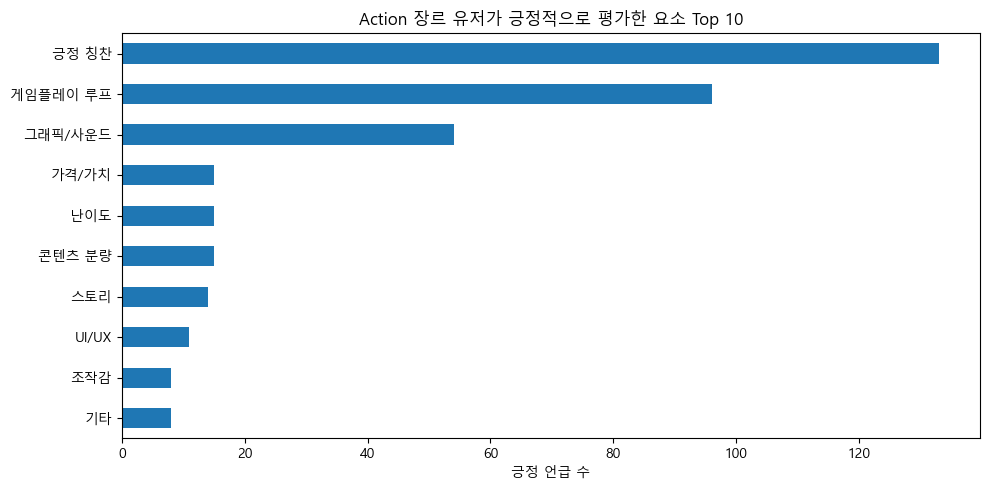

In [4]:
# ============================================================
# Action 장르 유저가 긍정적으로 평가한 요소
# ============================================================
positive_issue = (
    df_tags[df_tags["tag_sentiment"] == "positive"]
    .groupby(["tag_category", "issue_name_kor"], as_index=False)
    .agg(
        positive_count=("tag_category", "count"),
        mentioned_game_count=("appid", "nunique"),
    )
    .sort_values(["positive_count", "mentioned_game_count"], ascending=False)
    .head(10)
)

positive_issue = positive_issue.rename(columns={
    "issue_name_kor": "긍정 요소",
    "positive_count": "긍정 언급 수",
    "mentioned_game_count": "언급된 게임 수",
})

display(positive_issue[["긍정 요소", "긍정 언급 수", "언급된 게임 수"]])

ax = positive_issue.plot(
    kind="barh",
    x="긍정 요소",
    y="긍정 언급 수",
    legend=False,
)
ax.set_title("Action 장르 유저가 긍정적으로 평가한 요소 Top 10")
ax.set_xlabel("긍정 언급 수")
ax.set_ylabel("")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 결과 해석

Action 장르 표본에서 긍정적으로 많이 언급된 요소는 **긍정 칭찬(133), 게임플레이 루프(96), 그래픽/사운드(54)** 순으로 나타났다.

특히 게임플레이 루프는 긍정과 부정 양쪽에서 모두 많이 등장하므로, Action 장르에서 핵심 평가 축으로 볼 수 있다.  
즉, Action 게임 개발자는 출시 전 단계에서 전투, 이동, 반복 플레이 구조, 조작의 손맛, 페이싱이 짧은 플레이 안에도 충분히 전달되는지 점검해야 한다.

## 5. Action 장르 유저가 불편하게 느낀 요소

다음 표와 그래프는 LLM이 리뷰 본문에서 부정적으로 분류한 이슈 태그를 집계한 결과다.  
이 결과는 Action 장르 게임을 출시하기 전, 어떤 요소를 사전에 점검해야 하는지 판단하는 근거로 활용할 수 있다.

,불편 요소,부정 언급 수,언급된 게임 수,부정 비율
7,게임플레이 루프,47,18,31.1%
1,버그,29,10,93.5%
3,조작감,25,12,67.6%
17,UI/UX,22,11,62.9%
6,난이도,22,12,52.4%
2,콘텐츠 분량,22,11,47.8%
0,밸런스,11,8,84.6%
8,그래픽/사운드,10,8,14.9%
14,성장/반복 노가다,9,5,81.8%
15,저장/진행,7,6,100.0%


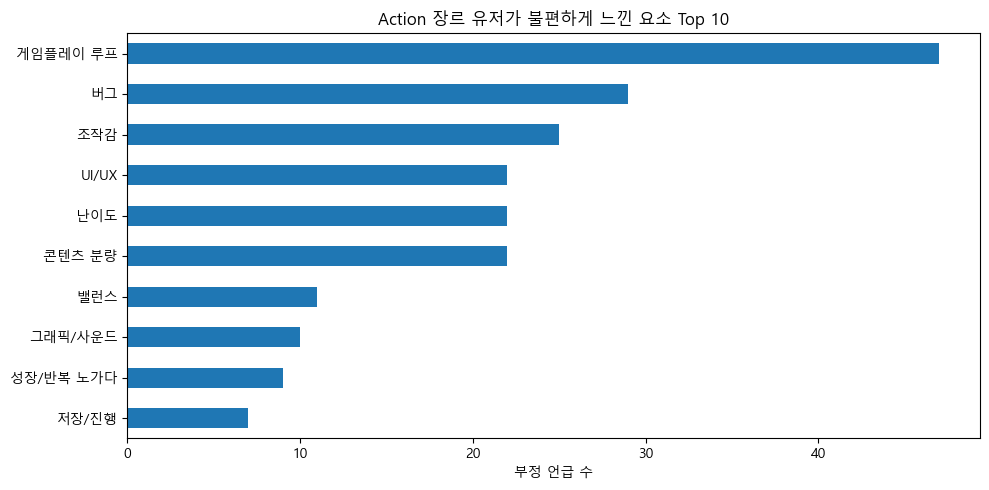

In [5]:
# ============================================================
# Action 장르 유저가 불편하게 느낀 요소
# ============================================================
negative_issue = (
    df_tags[df_tags["tag_sentiment"] == "negative"]
    .groupby(["tag_category", "issue_name_kor"], as_index=False)
    .agg(
        negative_count=("tag_category", "count"),
        mentioned_game_count=("appid", "nunique"),
    )
)

total_issue_count = (
    df_tags
    .groupby("tag_category")
    .size()
    .rename("total_count")
    .reset_index()
)

negative_issue = negative_issue.merge(total_issue_count, on="tag_category", how="left")
negative_issue["negative_rate"] = negative_issue["negative_count"] / negative_issue["total_count"]
negative_issue = negative_issue.sort_values(["negative_count", "negative_rate"], ascending=False).head(10)

negative_issue_display = negative_issue.rename(columns={
    "issue_name_kor": "불편 요소",
    "negative_count": "부정 언급 수",
    "mentioned_game_count": "언급된 게임 수",
    "negative_rate": "부정 비율",
})
negative_issue_display["부정 비율"] = negative_issue_display["부정 비율"].apply(lambda x: f"{x * 100:.1f}%")

display(negative_issue_display[["불편 요소", "부정 언급 수", "언급된 게임 수", "부정 비율"]])

plot_df = negative_issue.rename(columns={
    "issue_name_kor": "불편 요소",
    "negative_count": "부정 언급 수",
})

ax = plot_df.plot(
    kind="barh",
    x="불편 요소",
    y="부정 언급 수",
    legend=False,
)
ax.set_title("Action 장르 유저가 불편하게 느낀 요소 Top 10")
ax.set_xlabel("부정 언급 수")
ax.set_ylabel("")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 결과 해석

Action 장르 표본에서 부정적으로 많이 언급된 요소는 **게임플레이 루프(47), 버그(29), 조작감(25)** 순으로 나타났다.

이 결과는 출시 초기 부정 리뷰가 단순히 “게임이 재미없다”에서 끝나는 것이 아니라, 버그, 조작감, 난이도, UI/UX, 콘텐츠 밀도처럼 구체적인 경험 문제에서 발생할 수 있음을 보여준다.  
따라서 출시 전에는 핵심 재미뿐 아니라 조작 편의성, 튜토리얼/안내, 난이도 곡선, 버그 안정성, 콘텐츠 밀도를 함께 점검해야 한다.

## 6. 긍정과 부정이 함께 나타난 핵심 평가 축

일부 이슈는 긍정과 부정 양쪽에서 모두 많이 언급된다.  
이런 이슈는 단순한 장점이나 단점이 아니라, 유저 평가를 크게 좌우하는 핵심 축으로 해석하는 것이 적절하다.

tag_sentiment,이슈,전체 언급 수,긍정 언급 수,긍정 비율,부정 언급 수,부정 비율
7,게임플레이 루프,151,96,63.6%,47,31.1%
13,긍정 칭찬,134,133,99.3%,0,0.0%
8,그래픽/사운드,67,54,80.6%,10,14.9%
2,콘텐츠 분량,46,15,32.6%,22,47.8%
6,난이도,42,15,35.7%,22,52.4%
3,조작감,37,8,21.6%,25,67.6%
19,UI/UX,35,11,31.4%,22,62.9%
1,버그,31,1,3.2%,29,93.5%
11,기타,23,8,34.8%,7,30.4%
17,스토리,20,14,70.0%,4,20.0%


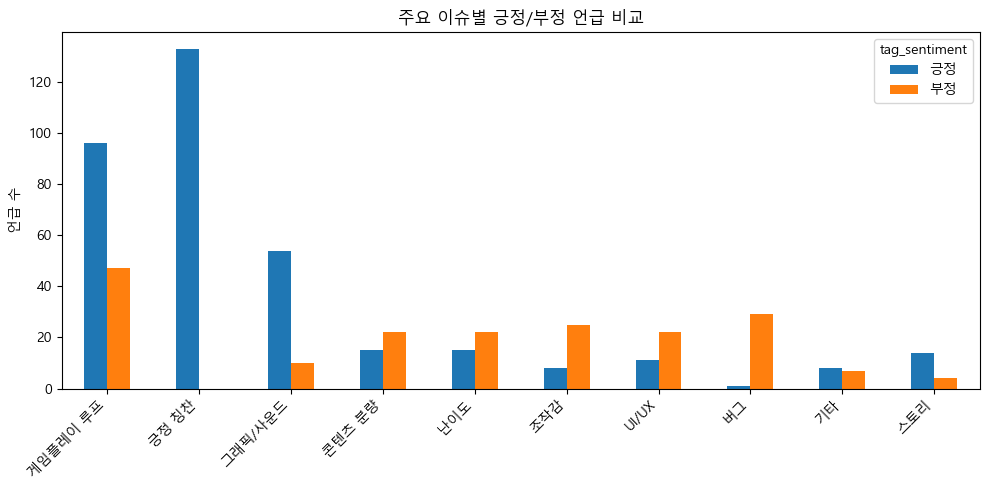

In [6]:
# ============================================================
# 주요 이슈별 긍정/부정 언급 비교
# ============================================================
issue_direction = (
    df_tags
    .pivot_table(
        index=["tag_category", "issue_name_kor"],
        columns="tag_sentiment",
        values="recommendationid",
        aggfunc="count",
        fill_value=0,
    )
    .reset_index()
)

for col in ["positive", "negative", "neutral", "mixed"]:
    if col not in issue_direction.columns:
        issue_direction[col] = 0

issue_direction["total_count"] = issue_direction[["positive", "negative", "neutral", "mixed"]].sum(axis=1)
issue_direction["negative_rate"] = issue_direction["negative"] / issue_direction["total_count"]
issue_direction["positive_rate"] = issue_direction["positive"] / issue_direction["total_count"]

issue_direction_top = (
    issue_direction
    .sort_values("total_count", ascending=False)
    .head(10)
    .copy()
)

issue_direction_display = issue_direction_top.rename(columns={
    "issue_name_kor": "이슈",
    "total_count": "전체 언급 수",
    "positive": "긍정 언급 수",
    "negative": "부정 언급 수",
    "positive_rate": "긍정 비율",
    "negative_rate": "부정 비율",
})
issue_direction_display["긍정 비율"] = issue_direction_display["긍정 비율"].apply(lambda x: f"{x * 100:.1f}%")
issue_direction_display["부정 비율"] = issue_direction_display["부정 비율"].apply(lambda x: f"{x * 100:.1f}%")

display(issue_direction_display[["이슈", "전체 언급 수", "긍정 언급 수", "긍정 비율", "부정 언급 수", "부정 비율"]])

plot_df = issue_direction_top.rename(columns={"issue_name_kor": "이슈", "positive": "긍정", "negative": "부정"})
ax = plot_df.set_index("이슈")[["긍정", "부정"]].plot(kind="bar")
ax.set_title("주요 이슈별 긍정/부정 언급 비교")
ax.set_ylabel("언급 수")
ax.set_xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 결과 해석

게임플레이 루프는 긍정과 부정 양쪽에서 모두 많이 언급되었다.  
이는 Action 장르에서 핵심 플레이 구조가 잘 설계되면 강점이 되지만, 반복성이 약하거나 전투·이동·성장 구조가 불편하면 곧바로 부정 평가로 이어질 수 있음을 의미한다.

반면 버그, 저장/진행, 크래시, 최적화와 같은 기술 안정성 계열 이슈는 부정 방향성이 강하다.  
따라서 출시 전 QA에서는 재미 검증뿐 아니라 진행 불가, 저장 오류, 충돌, 최적화 문제를 별도 체크리스트로 관리할 필요가 있다.

## 7. 출시 초기 구간별 이슈 변화

출시 초기 리뷰는 크게 `D0-D7`과 `D8-D30`으로 나누어 볼 수 있다.

- `D0-D7`: 출시 직후 첫인상, 조작, UI/UX, 초반 재미가 강하게 드러나는 구간
- `D8-D30`: 일정 시간 플레이한 뒤 반복성, 난이도, 버그, 콘텐츠 밀도 문제가 드러나는 구간

,리뷰 작성 구간,리뷰 수,게임 수,Steam 긍정률,LLM 긍정률,High 긴급도 비율
0,D0-D7,133,24,72.9%,63.9%,26.3%
1,D8-D30,73,19,71.2%,53.4%,31.5%


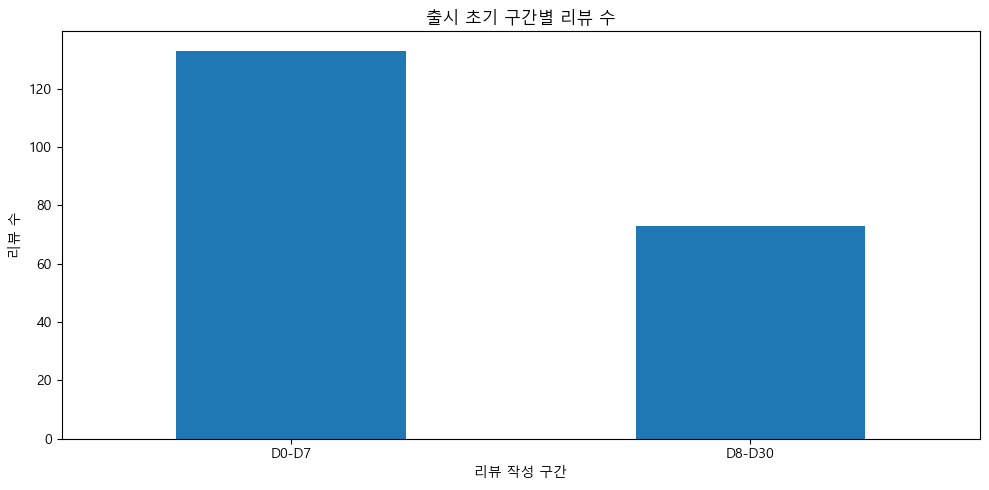

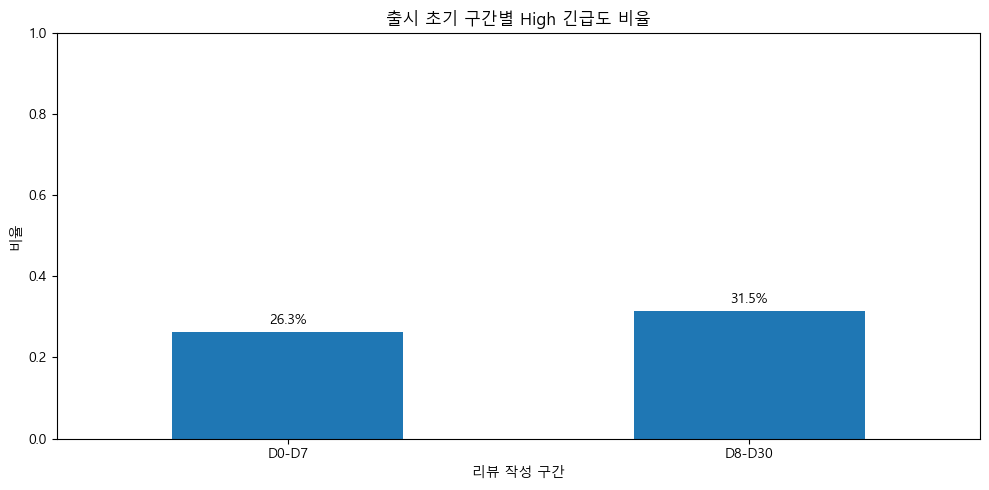

In [7]:
# ============================================================
# 출시 초기 구간별 전체 요약
# ============================================================
period_summary = (
    df_result
    .groupby("release_period", as_index=False)
    .agg(
        review_count=("recommendationid", "count"),
        game_count=("appid", "nunique"),
        steam_positive_rate=("steam_label_text", lambda x: (x == "positive").mean()),
        llm_positive_rate=("llm_sentiment", lambda x: (x == "positive").mean()),
        high_urgency_rate=("urgency", lambda x: (x == "high").mean()),
    )
)

period_summary_display = period_summary.copy()
period_summary_display = period_summary_display.rename(columns={
    "release_period": "리뷰 작성 구간",
    "review_count": "리뷰 수",
    "game_count": "게임 수",
    "steam_positive_rate": "Steam 긍정률",
    "llm_positive_rate": "LLM 긍정률",
    "high_urgency_rate": "High 긴급도 비율",
})
for col in ["Steam 긍정률", "LLM 긍정률", "High 긴급도 비율"]:
    period_summary_display[col] = period_summary_display[col].apply(lambda x: f"{x * 100:.1f}%")

display(period_summary_display)

# 리뷰 수 그래프
ax = period_summary.plot(kind="bar", x="release_period", y="review_count", legend=False, rot=0)
ax.set_title("출시 초기 구간별 리뷰 수")
ax.set_xlabel("리뷰 작성 구간")
ax.set_ylabel("리뷰 수")
plt.tight_layout()
plt.show()

# High 긴급도 비율 그래프
ax = period_summary.plot(kind="bar", x="release_period", y="high_urgency_rate", legend=False, rot=0)
ax.set_title("출시 초기 구간별 High 긴급도 비율")
ax.set_xlabel("리뷰 작성 구간")
ax.set_ylabel("비율")
ax.set_ylim(0, 1)
for i, value in enumerate(period_summary["high_urgency_rate"]):
    ax.text(i, value + 0.02, f"{value * 100:.1f}%", ha="center")
plt.tight_layout()
plt.show()

release_period,D0-D7,D8-D30
issue_name_kor,,
게임플레이 루프,28,19
버그,17,12
조작감,13,12
UI/UX,14,8
콘텐츠 분량,12,10
난이도,14,8
밸런스,9,2
그래픽/사운드,7,3
성장/반복 노가다,4,5


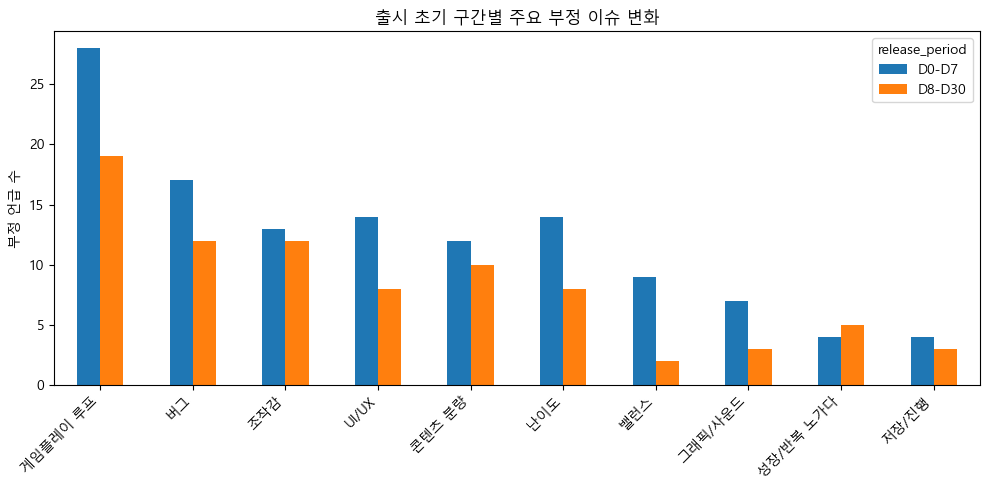

In [8]:
# ============================================================
# 출시 초기 구간별 부정 이슈 변화
# ============================================================
negative_tags = df_tags[df_tags["tag_sentiment"] == "negative"].copy()

period_negative_issue = pd.crosstab(
    negative_tags["issue_name_kor"],
    negative_tags["release_period"],
)

# 전체 부정 언급 수 기준 상위 10개만 확인한다.
period_negative_issue["total"] = period_negative_issue.sum(axis=1)
period_negative_issue_top = (
    period_negative_issue
    .sort_values("total", ascending=False)
    .drop(columns="total")
    .head(10)
)

display(period_negative_issue_top)

ax = period_negative_issue_top.plot(kind="bar")
ax.set_title("출시 초기 구간별 주요 부정 이슈 변화")
ax.set_ylabel("부정 언급 수")
ax.set_xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 결과 해석

D0-D7 구간에서는 **133개**, D8-D30 구간에서는 **73개**의 리뷰가 분석되었다.

D0-D7은 출시 직후 첫인상과 진입 경험을 보여주는 구간이고, D8-D30은 일정 시간 플레이한 뒤 누적되는 반복성, 난이도, 버그, 콘텐츠 밀도 문제를 보여주는 구간으로 볼 수 있다.  
따라서 출시 전 테스트는 첫 플레이 경험만 확인하는 것이 아니라, 일정 시간 이상 플레이했을 때 반복 피로도와 기술적 안정성 문제가 드러나는지도 함께 확인해야 한다.

## 8. 출시 전 점검 항목 도출

LLM 분석에서 반복적으로 확인된 긍정·부정 요소를 바탕으로, Action 장르 인디게임 개발자가 출시 전 단계에서 점검해야 할 항목을 정리하면 다음과 같다.

| 점검 영역        | 점검 질문                                           | 관련 이슈               |
| ------------ | ----------------------------------------------- | ------------------- |
| 핵심 플레이 루프    | 전투, 이동, 반복 플레이 구조가 짧은 시간 안에도 재미있게 전달되는가?        | 게임플레이 루프            |
| 조작감          | 키 조작, 카메라, 입력 반응, 이동 방식이 불편하지 않은가?              | 조작감                 |
| UI/UX와 튜토리얼  | 초반 목표, 메뉴, 인벤토리, 튜토리얼이 직관적으로 안내되는가?             | UI/UX               |
| 난이도 곡선       | 초반 난이도가 과도하게 높거나 너무 낮아 몰입을 방해하지 않는가?            | 난이도                 |
| 버그/진행 안정성    | 저장, 퀘스트 진행, 충돌, 진행 불가 버그가 없는가?                  | 버그, 저장/진행, 크래시, 최적화 |
| 콘텐츠 밀도       | 출시 초기에 충분한 콘텐츠, 반복 플레이 동기, 탐험/성장 요소가 있는가?       | 콘텐츠 분량, 성장/반복 노가다   |
| 그래픽/사운드와 분위기 | Action 장르 유저가 기대하는 타격감, 분위기, 사운드, 시각적 피드백이 있는가? | 그래픽/사운드, 스토리, 긍정 칭찬 |
| 가격 대비 가치     | 가격대에 비해 제공되는 콘텐츠와 완성도가 납득 가능한가?                 | 가격/가치               |


## 9. 핵심 인사이트

### 인사이트 1. Action 장르 유저는 핵심 플레이 루프를 가장 중요하게 평가한다

게임플레이 루프는 긍정 요소와 불편 요소 양쪽에서 모두 많이 언급되었다.  
이는 Action 장르에서 전투, 이동, 반복 플레이 구조, 조작의 손맛이 유저 평가의 중심이라는 것을 의미한다.

따라서 Action 인디게임 개발자는 출시 전 단계에서 핵심 플레이가 짧은 시간 안에 충분히 전달되는지 점검해야 한다.

### 인사이트 2. 조작감, UI/UX, 난이도는 출시 초기 부정 반응의 주요 리스크다

조작감, UI/UX, 난이도는 출시 초기 리뷰에서 반복적으로 부정 언급되었다.  
이는 게임의 아이디어가 좋더라도, 초반 조작 안내가 부족하거나 난이도 적응이 어렵다면 부정 리뷰로 이어질 수 있음을 의미한다.

따라서 출시 전에는 튜토리얼, 키 설정, 카메라, 입력 반응, 난이도 곡선, 피드백 UI를 우선 점검해야 한다.

### 인사이트 3. 긍정 리뷰 안에도 개선 요구가 포함될 수 있다

Steam에서 긍정으로 표시된 리뷰라도 LLM 기준으로는 mixed로 분류되는 경우가 존재했다.  
이는 유저가 게임을 추천하면서도 동시에 불편한 점을 남길 수 있다는 뜻이다.

따라서 유사 장르 게임을 벤치마킹할 때는 긍정률만 볼 것이 아니라, 긍정 리뷰 안에 반복적으로 등장하는 아쉬운 점까지 확인해야 한다.

### 인사이트 4. 출시 전 점검은 D0-D7 문제와 D8-D30 문제를 나누어 설계해야 한다

D0-D7에서는 첫인상, 조작, UI/UX, 초반 재미가 중요하고, D8-D30에서는 반복성, 콘텐츠 분량, 난이도, 버그 문제가 더 중요해질 수 있다.

따라서 출시 전 QA와 테스트는 단순 첫 플레이 테스트뿐 아니라, 일정 시간 이상 플레이했을 때의 반복 피로도와 콘텐츠 밀도까지 함께 확인해야 한다.

## 11. 결론 및 후속 분석 방향

이번 LLM 리뷰 감성분석은 Action 장르 인디게임의 출시 초기 리뷰를 바탕으로, 해당 장르 유저들이 긍정적으로 평가하는 요소와 불편하게 느끼는 요소를 도출하기 위해 수행하였다.

분석 결과, Action 장르에서는 **게임플레이 루프**가 가장 중요한 평가 축으로 나타났다.  
전투, 이동, 반복 플레이 구조, 조작의 손맛이 잘 전달되면 강점이 되지만, 반대로 불편하거나 반복성이 약하면 부정 리뷰로 이어질 수 있다.

또한 **조작감, UI/UX, 난이도, 버그, 콘텐츠 밀도**는 출시 초기 부정 반응으로 이어질 수 있는 주요 리스크로 확인되었다.  
따라서 Action 장르 게임을 개발하거나 출시 준비 중인 인디 개발사는 출시 전 단계에서 핵심 재미 요소뿐 아니라 초반 진입 경험, 기술적 안정성, 반복 플레이 만족도를 함께 점검해야 한다.

즉, 본 분석은 특정 게임의 출시 후 운영 처방이 아니라, **Action 장르 인디게임 개발자가 출시 전 전략과 QA 점검에 참고할 수 있는 장르 유저 반응 분석**으로 활용하는 것이 적절하다.

## 부록. 사용 데이터 파일

이 노트북은 아래 파일을 사용한다.

| 파일명 | 역할 |
|---|---|
| `llm_review_analysis_result.csv` | LLM 리뷰 감성분석 결과 원본 |
| `llm_issue_tags_flat.csv` | 리뷰별 issue_tags를 태그 단위로 펼친 결과 |
| `llm_game_summary.csv` | 게임 단위 요약 결과 |
| `llm_issue_priority_summary.csv` | 이슈별 긍정/부정 방향성 요약 |